<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Number of Features: 38
Reduced Number of Features (90% Variance): 23
Information Compression: 39.47%


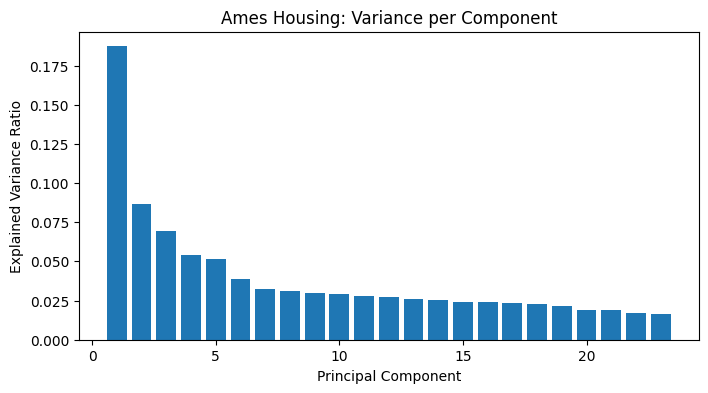

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
df=pd.read_csv('AmesHousing.csv')

# --- 1. DATA PREPARATION ---
# Select only numerical features for PCA
numeric_df = df.select_dtypes(include=[np.number])
X = numeric_df.drop('SalePrice', axis=1)
y = numeric_df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 2. THE PCA PRODUCTION PIPELINE ---
# We use 0.90 to let the math decide how many components we need
pca_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90))
])

# Fit and Transform
X_train_pca = pca_pipeline.fit_transform(X_train)
X_test_pca = pca_pipeline.transform(X_test)

# --- 3. AUDIT THE RESULTS ---
pca_step = pca_pipeline.named_steps['pca']
n_cols_original = X_train.shape[1]
n_cols_pca = X_train_pca.shape[1]

print(f"Original Number of Features: {n_cols_original}")
print(f"Reduced Number of Features (90% Variance): {n_cols_pca}")
print(f"Information Compression: {((n_cols_original - n_cols_pca) / n_cols_original) * 100:.2f}%")

# --- 4. VISUALIZING COMPONENT IMPORTANCE ---
exp_var = pca_step.explained_variance_ratio_
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(exp_var) + 1), exp_var)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Ames Housing: Variance per Component')
plt.show()

In [4]:
# See which original features contribute most to the 1st Principal Component
loadings = pd.Series(pca_step.components_[1], index=X_train.columns)
print("Top features in PC1:\n", loadings.abs().sort_values(ascending=False).head(5))

Top features in PC1:
 2nd Flr SF        0.432119
Bedroom AbvGr     0.373453
TotRms AbvGrd     0.344631
BsmtFin SF 1      0.285617
Bsmt Full Bath    0.272795
dtype: float64


In [5]:
variance = X_train.var().sort_values(ascending=False)
top_10_features = variance.head(10).index.tolist()

X_train = X_train[top_10_features]
X_test = X_test[top_10_features]

print("X_train after dropping features with low variance:")
print(X_train.head())
print("\nX_test after dropping features with low variance:")
print(X_test.head())
print(f"\nNumber of features after variance-based selection: {X_train.shape[1]}")

X_train after dropping features with low variance:
            PID  Lot Area  Order  Misc Val  Gr Liv Area  BsmtFin SF 1  \
381   527359050     10400    382         0         1370           0.0   
834   906475070     28698    835         0         2126         249.0   
1898  534429030      9842   1899         0         1224           0.0   
678   535451170      7200    679         0         1040           0.0   
700   902109130      7627    701         0         1701           0.0   

      Total Bsmt SF  Bsmt Unf SF  2nd Flr SF  1st Flr SF  
381          1090.0       1090.0           0        1370  
834          1013.0          0.0         966        1160  
1898            0.0          0.0           0        1224  
678             0.0          0.0           0        1040  
700           600.0        600.0         600        1101  

X_test after dropping features with low variance:
            PID  Lot Area  Order  Misc Val  Gr Liv Area  BsmtFin SF 1  \
1357  903427090      5100   1358

### Comparing Ridge Regression Performance Before and After PCA

In [6]:
# Re-create the original train-test split to use for the 'before PCA' model
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Ridge Regression BEFORE PCA ---
# Build a pipeline for imputation, scaling, and Ridge Regression for the original data
ridge_pipeline_original = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(random_state=42))
])

# Fit the model
ridge_pipeline_original.fit(X_train_original, y_train_original)

# Make predictions
y_pred_original = ridge_pipeline_original.predict(X_test_original)

# Evaluate the model
from sklearn.metrics import r2_score, mean_squared_error
r2_original = r2_score(y_test_original, y_pred_original)
rmse_original = np.sqrt(mean_squared_error(y_test_original, y_pred_original))

print("--- Ridge Regression BEFORE PCA/Variance Selection ---")
print(f"R-squared: {r2_original:.4f}")
print(f"RMSE: {rmse_original:.2f}")

--- Ridge Regression BEFORE PCA/Variance Selection ---
R-squared: 0.8371
RMSE: 36134.76


In [7]:
# --- Ridge Regression AFTER PCA ---
# X_train_pca and X_test_pca are already imputed and scaled by the pca_pipeline

# Build a Ridge Regression model for PCA-transformed data
ridge_pca = Ridge(random_state=42)

# Fit the model
ridge_pca.fit(X_train_pca, y_train)

# Make predictions
y_pred_pca = ridge_pca.predict(X_test_pca)

# Evaluate the model
r2_pca = r2_score(y_test, y_pred_pca)
rmse_pca = np.sqrt(mean_squared_error(y_test, y_pred_pca))

print("\n--- Ridge Regression AFTER PCA ---")
print(f"R-squared: {r2_pca:.4f}")
print(f"RMSE: {rmse_pca:.2f}")


--- Ridge Regression AFTER PCA ---
R-squared: 0.8253
RMSE: 37424.91


### Comparison Summary

Based on the R-squared and RMSE values, we can compare the performance of the Ridge Regression model with and without PCA. A higher R-squared and lower RMSE generally indicate a better-performing model.

In [8]:
import kagglehub
path = kagglehub.dataset_download("zalando-research/fashionmnist")

Using Colab cache for faster access to the 'fashionmnist' dataset.


In [9]:
import os
print(os.listdir(path))

['t10k-labels-idx1-ubyte', 't10k-images-idx3-ubyte', 'fashion-mnist_test.csv', 'fashion-mnist_train.csv', 'train-labels-idx1-ubyte', 'train-images-idx3-ubyte']


In [10]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(path, 'fashion-mnist_train.csv'))


In [11]:
df.sample(2)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
47165,2,0,0,0,0,0,0,0,0,0,...,3,5,0,0,179,196,84,0,0,0
5894,6,0,0,0,0,0,0,0,1,0,...,23,28,0,0,0,0,1,0,0,0


In [12]:
import matplotlib.pyplot as plt
import numpy as np


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [14]:
X_train,X_test,y_train,y_test=train_test_split(df.drop('label', axis=1),df['label'],random_state=42,test_size=0.2)

In [15]:
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [16]:
pred=lr.predict(X_test)

In [17]:
r2_score(y_test,pred)

0.7630987507835106

# first implement the  standard scaling

In [18]:
st=StandardScaler()
X_train_st=st.fit_transform(X_train)
X_test_st=st.transform(X_test)

# applying the pca

In [19]:
pc=PCA(n_components=2)

In [20]:
x_train_pc=pc.fit_transform(X_train_st)
x_test_pc=pc.transform(X_test_st)

In [21]:
lr=LinearRegression()
lr.fit(x_train_pc,y_train)

LinearRegression()

In [22]:
pred_1=lr.predict(x_test_pc)

In [23]:
r2_score(y_test,pred_1)

0.606034494297929

In [24]:
df.shape

(60000, 785)

Number of components: 1, R2 Score: 0.1191
Number of components: 2, R2 Score: 0.6060
Number of components: 3, R2 Score: 0.6289
Number of components: 4, R2 Score: 0.6296
Number of components: 5, R2 Score: 0.6587
Number of components: 6, R2 Score: 0.6879
Number of components: 7, R2 Score: 0.6892
Number of components: 8, R2 Score: 0.6891
Number of components: 9, R2 Score: 0.7040
Number of components: 10, R2 Score: 0.7058
Number of components: 11, R2 Score: 0.7083
Number of components: 12, R2 Score: 0.7104
Number of components: 13, R2 Score: 0.7107
Number of components: 14, R2 Score: 0.7117
Number of components: 15, R2 Score: 0.7137
Number of components: 16, R2 Score: 0.7142
Number of components: 17, R2 Score: 0.7206
Number of components: 18, R2 Score: 0.7206
Number of components: 19, R2 Score: 0.7257
Number of components: 20, R2 Score: 0.7271
Number of components: 21, R2 Score: 0.7274
Number of components: 22, R2 Score: 0.7274
Number of components: 23, R2 Score: 0.7278
Number of components

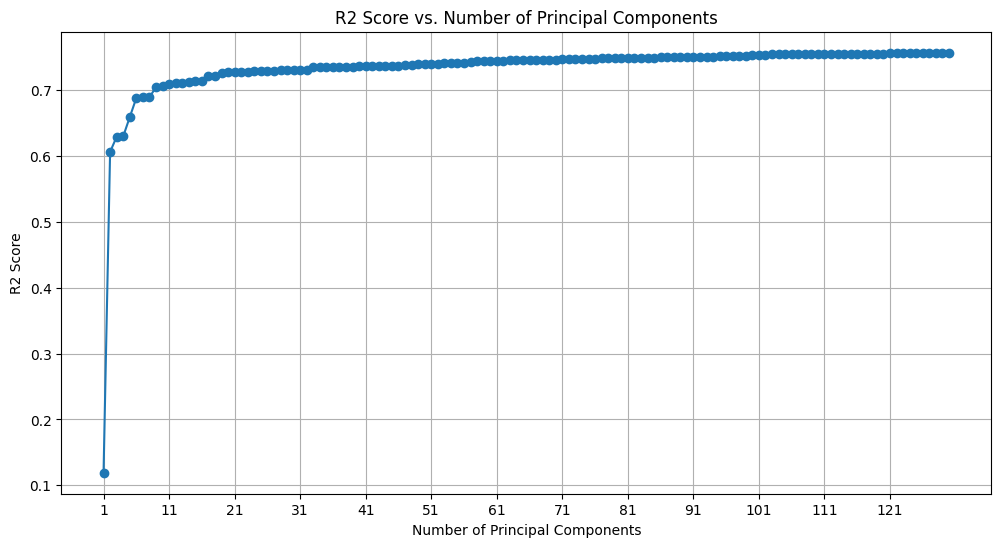


General Observation:
---------------------
As the number of principal components increases, the R2 score generally improves, indicating that more variance from the original data is being captured, which leads to better model performance.
You can observe significant changes (improvements) particularly when moving from 1 to 2 or 2 to 3 components, and then the improvements might become more gradual.


In [25]:
r2_scores_pca = []
for i in range(1, 131): # Changed range to include up to 130 components
  pc = PCA(n_components=i) # Use 'i' as the number of components
  x_train_pc = pc.fit_transform(X_train_st)
  x_test_pc = pc.transform(X_test_st)
  lr = LinearRegression()
  lr.fit(x_train_pc, y_train)
  pred_1 = lr.predict(x_test_pc)
  score = r2_score(y_test, pred_1)
  r2_scores_pca.append((i, score))
  print(f"Number of components: {i}, R2 Score: {score:.4f}")

# Visualize the change in R2 score with an increasing number of components
import matplotlib.pyplot as plt

components = [item[0] for item in r2_scores_pca]
scores = [item[1] for item in r2_scores_pca]

plt.figure(figsize=(12, 6))
plt.plot(components, scores, marker='o', linestyle='-')
plt.xlabel('Number of Principal Components')
plt.ylabel('R2 Score')
plt.title('R2 Score vs. Number of Principal Components')
plt.grid(True)
plt.xticks(range(1, 131, 10)) # Adjust ticks for wider range
plt.show()

print("\nGeneral Observation:")
print("---------------------")
print("As the number of principal components increases, the R2 score generally improves, indicating that more variance from the original data is being captured, which leads to better model performance.")
print("You can observe significant changes (improvements) particularly when moving from 1 to 2 or 2 to 3 components, and then the improvements might become more gradual.")

In [26]:
x_test_pc

array([[-1.81382532e+01,  2.30745298e+00,  6.85373156e-03, ...,
        -9.71556906e-01, -1.59298694e-01, -9.39716434e-01],
       [ 1.29932277e+01,  3.13335314e+01, -2.20735838e+00, ...,
        -3.33491983e+00,  2.69666292e+00,  2.81624663e+00],
       [ 2.38579587e+00,  2.04318687e+01, -4.61513838e+00, ...,
        -6.53790070e-02,  2.14290025e-01, -1.54849632e+00],
       ...,
       [-1.48217781e+01,  1.00535227e+01, -5.63911476e+00, ...,
        -7.72644029e-01, -5.66996372e-01,  9.77663014e-01],
       [-2.26613644e+01, -3.18396826e+00,  5.33437442e+00, ...,
        -7.38434556e-01, -1.80954666e-01,  1.16794674e+00],
       [-1.55332059e+01,  8.73380944e-01,  2.32404830e+00, ...,
         1.10137028e+00, -5.17389358e-01, -1.10823646e+00]])

In [27]:
x_test_pc.shape

(12000, 130)

In [28]:
import plotly.express as px
import numpy as np
import pandas as pd # Ensure pandas is imported as it's used below

# Define the Fashion MNIST class labels mapping
fashion_mnist_labels = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

# Ensure x_train_pc has at least 3 components
if x_train_pc.shape[1] < 3:
    print("Not enough principal components for a 3D plot. Need at least 3.")
else:
    # Create a DataFrame for Plotly for easier plotting
    df_pca = pd.DataFrame(x_train_pc[:, :3], columns=['PC1', 'PC2', 'PC3'])
    df_pca['Class Label'] = y_train.values # Ensure y_train is a numpy array or Series for consistency
    df_pca['Class Name'] = df_pca['Class Label'].map(fashion_mnist_labels)

    fig = px.scatter_3d(df_pca, x='PC1', y='PC2', z='PC3',
                        color='Class Name', # Color points by the descriptive class name
                        hover_name='Class Name', # Display descriptive name on hover
                        hover_data=['Class Label', 'PC1', 'PC2', 'PC3'], # Include original label and PC values on hover
                        title='3D PCA Visualization of Training Data (First 3 Components)',
                        labels={'PC1': 'Principal Component 1',
                                'PC2': 'Principal Component 2',
                                'PC3': 'Principal Component 3'})

    fig.show()

In [30]:
print("Eigenvectors (Principal Components):")
print(pc.explained_variance_ratio_)

Eigenvectors (Principal Components):
[0.2205224  0.14418337 0.054465   0.0512002  0.04060954 0.0303058
 0.0275825  0.02329127 0.01686419 0.01313153 0.01161474 0.00960395
 0.00888867 0.00863218 0.00746448 0.0073299  0.00657236 0.00633718
 0.00628288 0.00579546 0.00519098 0.00515163 0.00471762 0.00453302
 0.0043851  0.00415818 0.0039664  0.00394868 0.00380149 0.00374311
 0.00367022 0.0035573  0.00335917 0.00331772 0.00330991 0.00319917
 0.00305236 0.00294404 0.00288961 0.00281709 0.00271804 0.0026676
 0.00256869 0.00252914 0.00245876 0.00243544 0.00238921 0.00228092
 0.002233   0.00216136 0.00212223 0.00208117 0.00202794 0.00201007
 0.001998   0.00194351 0.00191871 0.00185316 0.00182044 0.00179359
 0.001759   0.00174122 0.00171753 0.00167105 0.00161145 0.0015795
 0.00154654 0.00150202 0.00149448 0.00145577 0.00144236 0.00143631
 0.00142449 0.0014035  0.00138575 0.00137231 0.00134874 0.00130698
 0.00129901 0.00126749 0.00125106 0.00122687 0.001212   0.00119805
 0.00118158 0.00114221 0.001

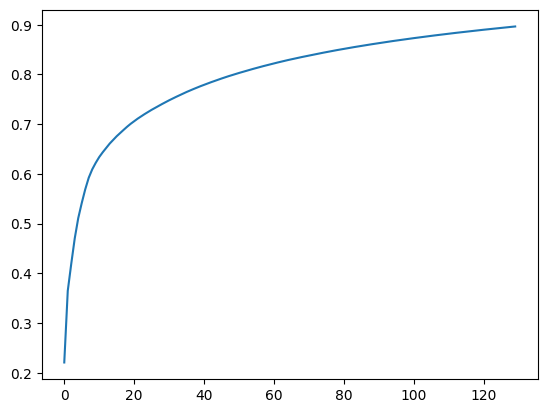

In [32]:
plt.plot(np.cumsum(pc.explained_variance_ratio_))